CWDM using lattice filters

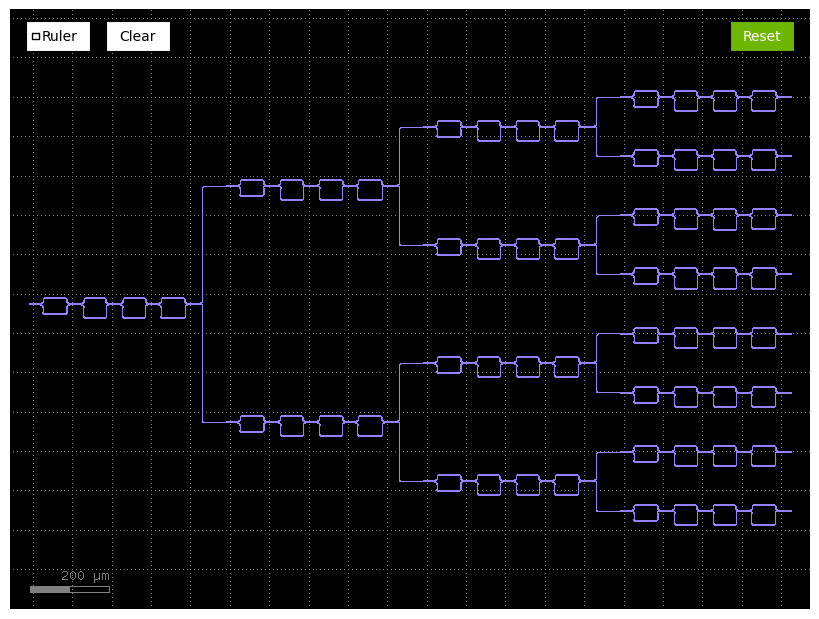

In [1]:
import gdsfactory as gf
import numpy as np
from gdsfactory.typings import ComponentSpec
from typing import Dict, Optional, Tuple
import cspdk.si220.cband
from axiomatic.pic_helpers import plot_circuit

# Activate CSPDK
cspdk.si220.cband.activate_pdk()
pdk = gf.get_active_pdk()

def get_output_ports(parent: gf.ComponentReference) -> Tuple[str, str]:
    num_ports = len(parent.ports)
    return ("o3", "o4") if num_ports == 4 else ("o2", "o3")

def splitter_1xn(
    n_outputs: int,
    cell: ComponentSpec = "mzi",
    cell_settings: Optional[Dict[int, Dict]] = None,
    x_spacing: float = 90.0,
    y_spacing: float = 50.0,
) -> gf.Component:
    depth = int(np.log2(n_outputs))
    c = gf.Component()
    cell_refs = {}

    # Place cells in binary tree layout
    for level in range(depth + 1):
        num_cells = 2 ** level
        y_base = -(2 ** depth - 1) * y_spacing / 2
        stage_settings = cell_settings.get(level, {}) if cell_settings else {}

        for i in range(num_cells):
            x = level * x_spacing
            y = y_base + (2 ** (depth - level)) * y_spacing * (i + 0.5)
            ref = c << cell(**stage_settings)
            ref.name = f"cell_{level}_{i}"
            ref.move((x, y))
            cell_refs[(level, i)] = ref

    # Route ports from parents to children
    for level in range(depth):
        for i in range(2 ** level):
            parent = cell_refs[(level, i)]
            child_left = cell_refs[(level + 1, 2 * i)]
            child_right = cell_refs[(level + 1, 2 * i + 1)]

            out1, out2 = get_output_ports(parent)

            gf.routing.route_single(
                c, port1=parent.ports[out2], port2=child_left.ports["o1"],
                cross_section="strip", bend="bend_euler"
            )
            gf.routing.route_single(
                c, port1=parent.ports[out1], port2=child_right.ports["o1"],
                cross_section="strip", bend="bend_euler"
            )

    # Add input port
    c.add_port("in0", port=cell_refs[(0, 0)].ports["o1"])

    # Add output ports
    for i in range(2 ** depth):
        leaf = cell_refs[(depth, i)]
        c.add_port(f"out{i * 2}", port=leaf.ports["o2"])
        c.add_port(f"out{i * 2 + 1}", port=leaf.ports["o3"])

    return c

def mzi_lattice_filter(
    delta_lengths: list[float],
    coupling_lengths: list[float],
    center_wvl: float = 1.55,
    coupling_gap: float = 0.2,
    n_g: float = 4.3,
    bend_radius: float = 5.0
) -> gf.Component:
    assert len(coupling_lengths) == len(delta_lengths) + 1, \
        "Need one more coupler than delay sections"

    c = gf.Component()
    coupler = lambda L: pdk.get_component("coupler", length=L, gap=coupling_gap)
    stage_spacing = 100
    couplers = []

    # Place couplers
    for i, L in enumerate(coupling_lengths):
        dc = c << coupler(L)
        dc.move((i * stage_spacing, 0))
        couplers.append(dc)

    # Add main and alias ports
    c.add_port("in0", port=couplers[0].ports["o2"])
    c.add_port("in1", port=couplers[0].ports["o1"])
    c.add_port("out0", port=couplers[-1].ports["o3"])
    c.add_port("out1", port=couplers[-1].ports["o4"])

    # Add aliases to match splitter_1xn port expectations
    c.add_port("o1", port=couplers[0].ports["o1"])
    c.add_port("o2", port=couplers[-1].ports["o3"])
    c.add_port("o3", port=couplers[-1].ports["o4"])

    # Create delay arms
    for i, delta_L in enumerate(delta_lengths):
        top_src = couplers[i].ports["o3"]
        bot_src = couplers[i].ports["o4"]
        top_dst = couplers[i + 1].ports["o2"]
        bot_dst = couplers[i + 1].ports["o1"]
        detour_y = 15

        x0, y0 = top_src.center
        x1, y1 = top_dst.center
        steps_top = [
            {"x": x0 + bend_radius},
            {"y": detour_y},
            {"x": x1 - bend_radius},
            {"y": y1},
        ]
        gf.routing.route_single(
            component=c,
            port1=top_src,
            port2=top_dst,
            steps=steps_top,
            bend="bend_euler",
            cross_section="strip"
        )

        x0, y0 = bot_src.center
        x1, y1 = bot_dst.center
        steps_bot = [
            {"x": x0 + bend_radius},
            {"y": -detour_y - delta_L / 2},
            {"x": x1 - bend_radius},
            {"y": y1},
        ]
        gf.routing.route_single(
            component=c,
            port1=bot_src,
            port2=bot_dst,
            steps=steps_bot,
            bend="bend_euler",
            cross_section="strip"
        )

    return c

if __name__ == "__main__":
    # Example: Use lattice filters directly in the binary tree splitter
    lambda_c = 1.301
    n_eff = 2.38
    delta_L = 21.0
    delta_L_pi = lambda_c / (2 * n_eff)
    delta_lengths = [
        delta_L,
        2 * delta_L,
        2 * delta_L + delta_L_pi,
        2 * delta_L
    ]
    coupling_lengths = [10, 13, 12, 10, 15]

    lattice_filter_factory = lambda: mzi_lattice_filter(
        delta_lengths=delta_lengths,
        coupling_lengths=coupling_lengths
    )

    demux_lattice = splitter_1xn(
        n_outputs=8,
        cell=lattice_filter_factory,
        x_spacing=500,
        y_spacing=150
    )

    plot_circuit(demux_lattice)
